# Aussie Rain

## Problem Statement

> The [Rain in Australia dataset](https://kaggle.com/jsphyg/weather-dataset-rattle-package) contains about 10 years of daily weather observations from numerous Australian weather stations.

> As a data scientist at the Bureau of Meteorology, you are tasked with creating a fully-automated system that can use today's weather data for a given location to predict whether it will rain at the location tomorrow.



In [ ]:
pip install opendatasets --upgrade --quiet

In [ ]:
pip install jupyter_black --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.2 MB/s eta 0:00:00


In [ ]:
import opendatasets as od
import os
import pandas as pd
import numpy as np
import jupyter_black

jupyter_black.load()

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
# Model saving
from joblib import dump, load


# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("darkgrid")
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.facecolor"] = "#00000000"

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [ ]:
dataset_url = "https://www.kaggle.com/jsphyg/weather-dataset-rattle-package"

In [ ]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sebastangarrido
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package


100%|██████████| 3.83M/3.83M [00:00<00:00, 68.0MB/s]

In [ ]:
data_dir = "./weather-dataset-rattle-package"

In [ ]:
os.listdir(data_dir)

['weatherAUS.csv']

In [ ]:
train_csv = data_dir + "/weatherAUS.csv"

In [ ]:
df = pd.read_csv(train_csv)

In [ ]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## EDA

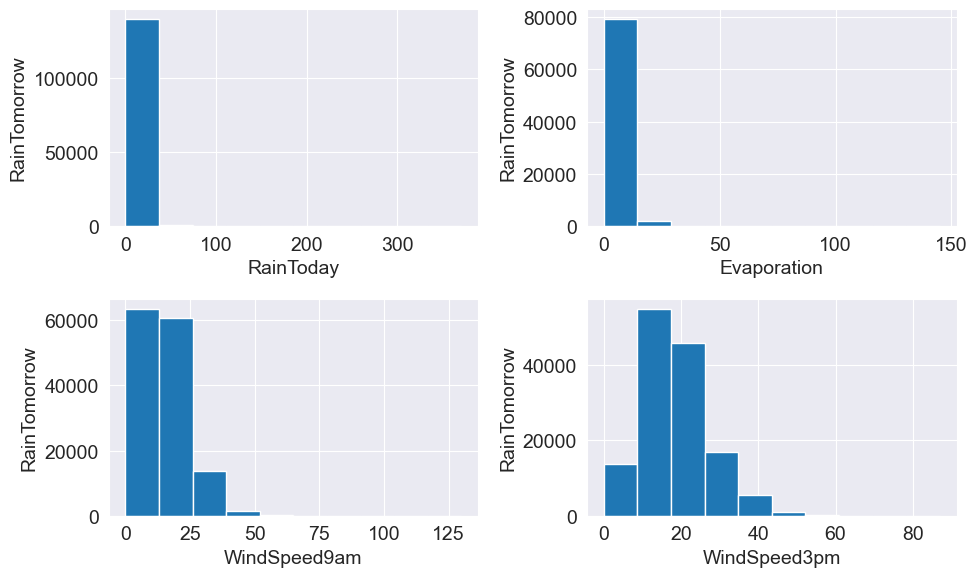

In [ ]:
# Plot histogram to check distribution
plt.subplot(2, 2, 1)
fig = df.Rainfall.hist(bins=10)
fig.set_xlabel("RainToday")
fig.set_ylabel("RainTomorrow")


plt.subplot(2, 2, 2)
fig = df.Evaporation.hist(bins=10)
fig.set_xlabel("Evaporation")
fig.set_ylabel("RainTomorrow")


plt.subplot(2, 2, 3)
fig = df.WindSpeed9am.hist(bins=10)
fig.set_xlabel("WindSpeed9am")
fig.set_ylabel("RainTomorrow")


plt.subplot(2, 2, 4)
fig = df.WindSpeed3pm.hist(bins=10)
fig.set_xlabel("WindSpeed3pm")
fig.set_ylabel("RainTomorrow")

plt.tight_layout()
plt.show()

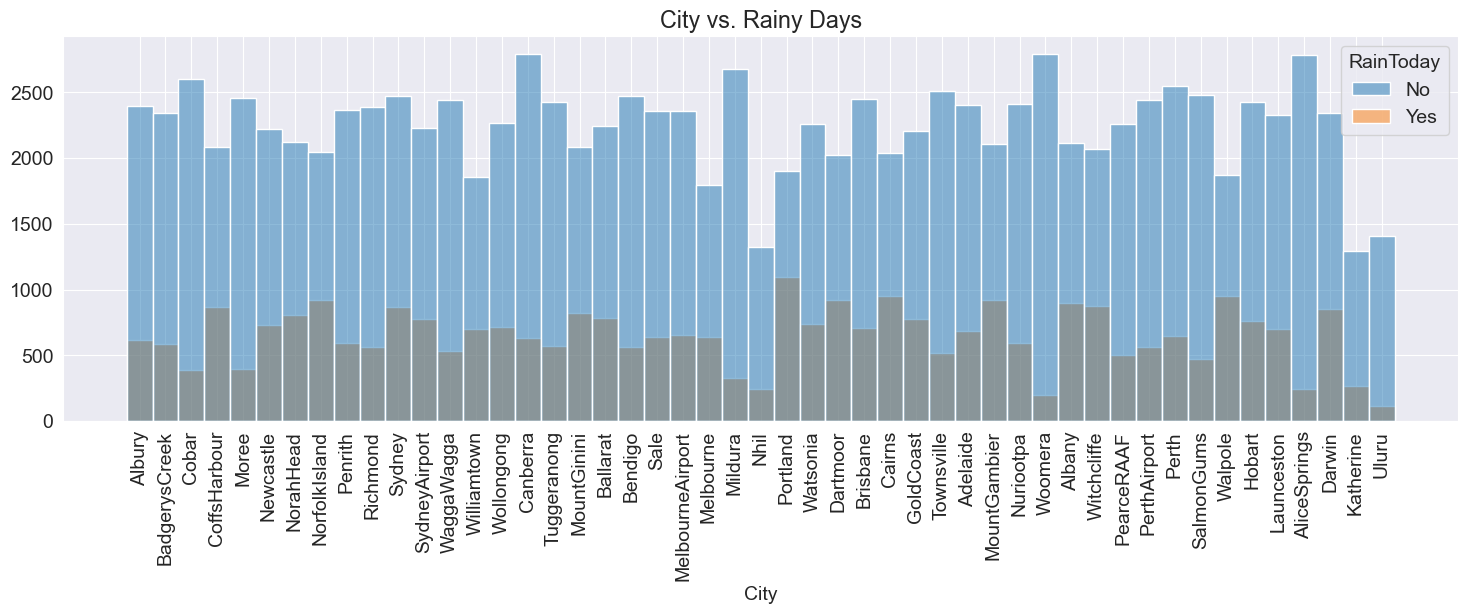

In [ ]:
plt.figure(figsize=(18, 5))
sns.histplot(df, x="Location", hue="RainToday")
plt.title("City vs. Rainy Days")
plt.xlabel("City")
plt.ylabel(None)
plt.xticks(rotation=90)
plt.show()

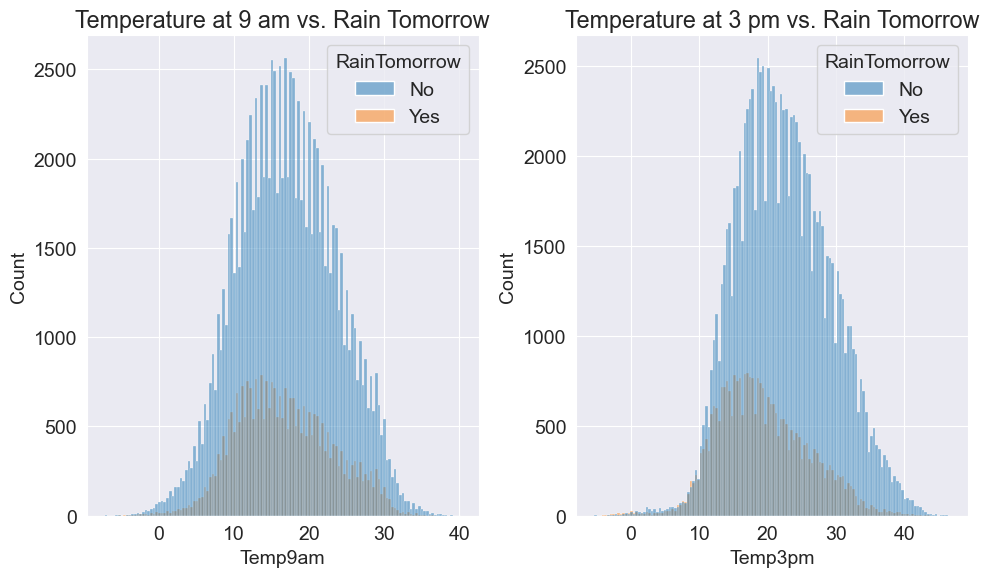

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2)

# Plot for Temp9am
sns.histplot(df, x="Temp9am", hue="RainTomorrow", ax=axes[0])
axes[0].set_title("Temperature at 9 am vs. Rain Tomorrow")

# Plot for Temp3pm
sns.histplot(df, x="Temp3pm", hue="RainTomorrow", ax=axes[1])
axes[1].set_title("Temperature at 3 pm vs. Rain Tomorrow")

plt.tight_layout()
plt.show()

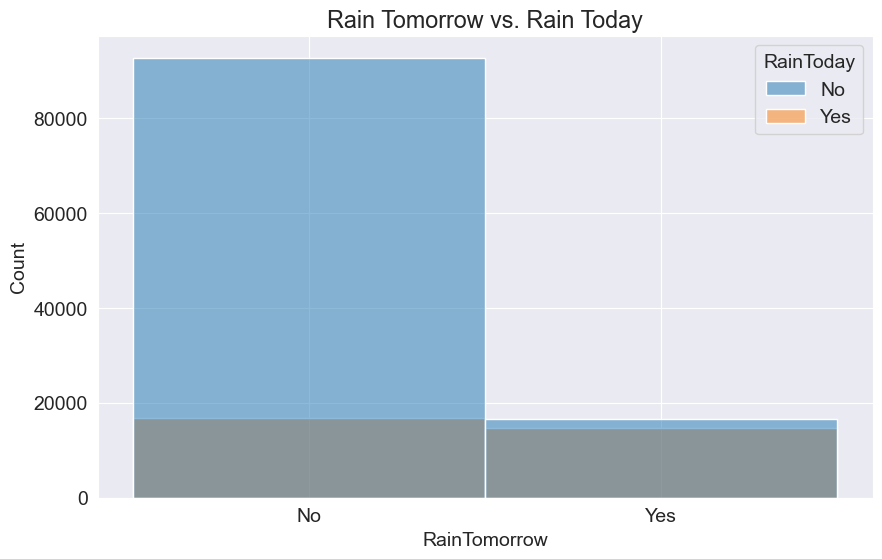

In [ ]:
sns.histplot(df, x="RainTomorrow", hue="RainToday")
plt.title("Rain Tomorrow vs. Rain Today")
plt.show()

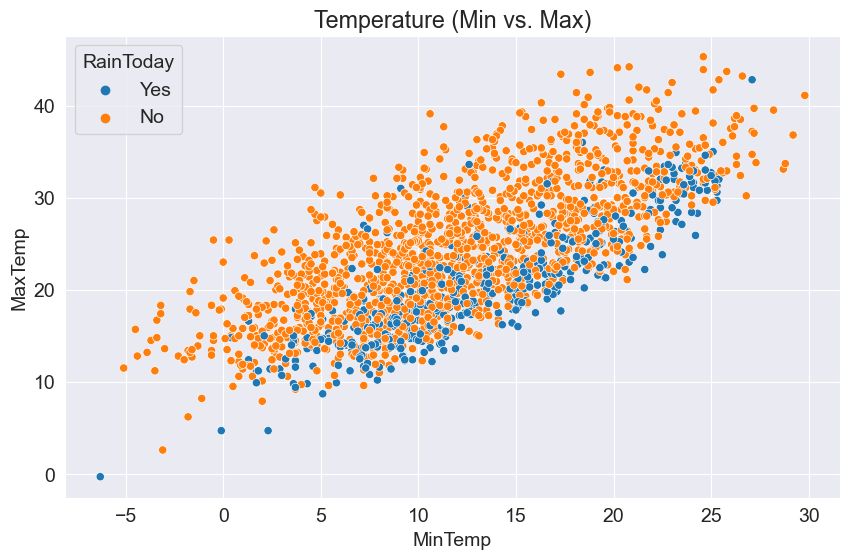

In [ ]:
sns.scatterplot(df.sample(2000), x="MinTemp", y="MaxTemp", hue="RainToday")
plt.title("Temperature (Min vs. Max)")
plt.show()

In [ ]:
def plot_temp_pressure_scatter(
    df,
    x1,
    y1,
    x2,
    y2,
    title1,
    title2,
    hue="RainToday",
    sample_size=2000,
    figsize=(12, 7),
):
    fig, axes = plt.subplots(2, 1, figsize=figsize)

    # Scatter plot for the first pair of variables
    sns.scatterplot(df.sample(sample_size), x=x1, y=y1, hue=hue, ax=axes[0])
    axes[0].set_title(title1)

    # Scatter plot for the second pair of variables
    sns.scatterplot(df.sample(sample_size), x=x2, y=y2, hue=hue, ax=axes[1])
    axes[1].set_title(title2)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    return fig, axes

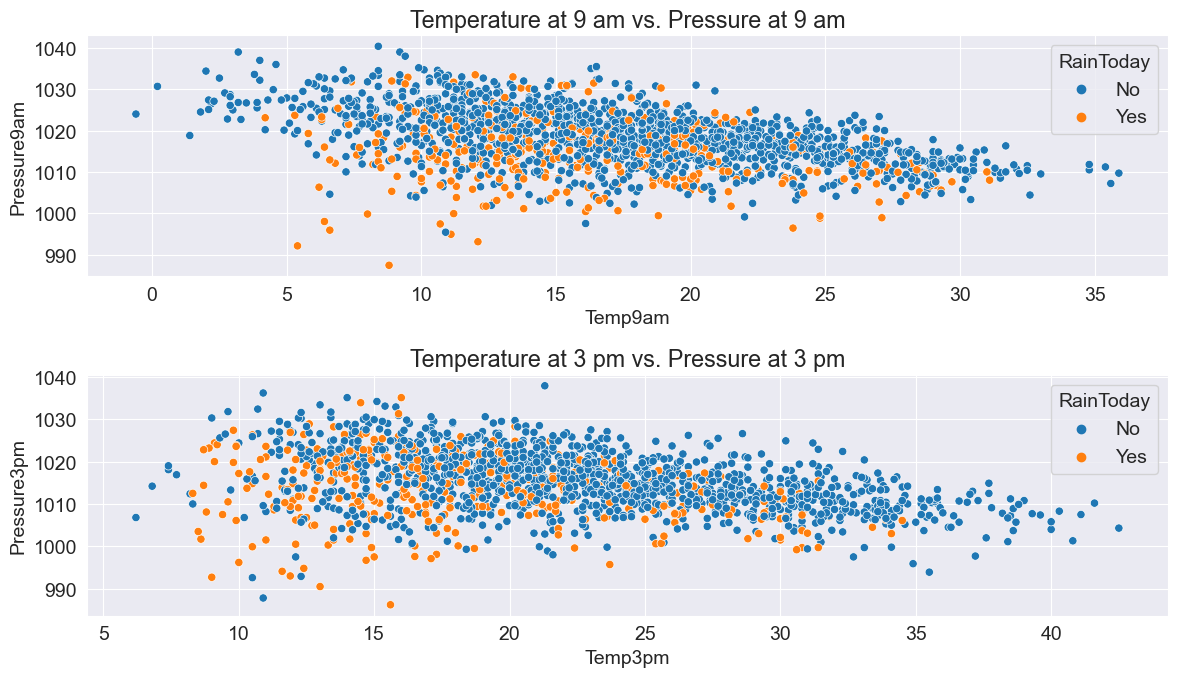

In [ ]:
fig, axes = plot_temp_pressure_scatter(
    df,
    x1="Temp9am",
    y1="Pressure9am",
    x2="Temp3pm",
    y2="Pressure3pm",
    title1="Temperature at 9 am vs. Pressure at 9 am",
    title2="Temperature at 3 pm vs. Pressure at 3 pm",
)
plt.show()

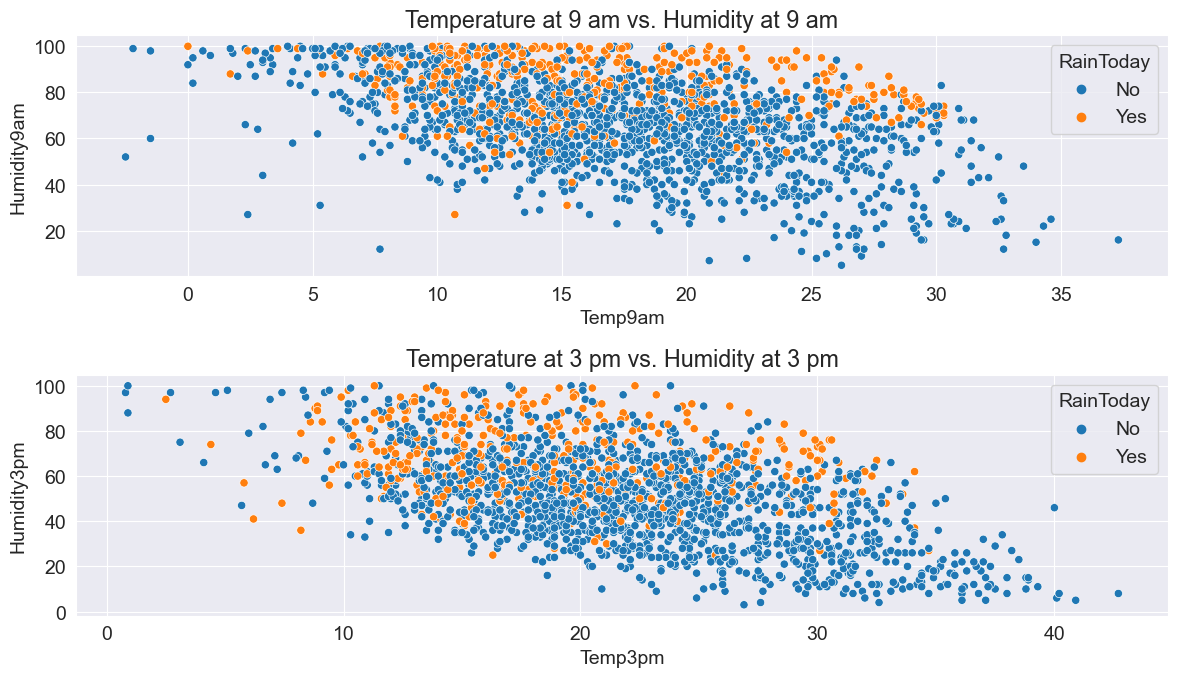

In [ ]:
fig, axes = plot_temp_pressure_scatter(
    df,
    x1="Temp9am",
    y1="Humidity9am",
    x2="Temp3pm",
    y2="Humidity3pm",
    title1="Temperature at 9 am vs. Humidity at 9 am",
    title2="Temperature at 3 pm vs. Humidity at 3 pm",
)
plt.show()

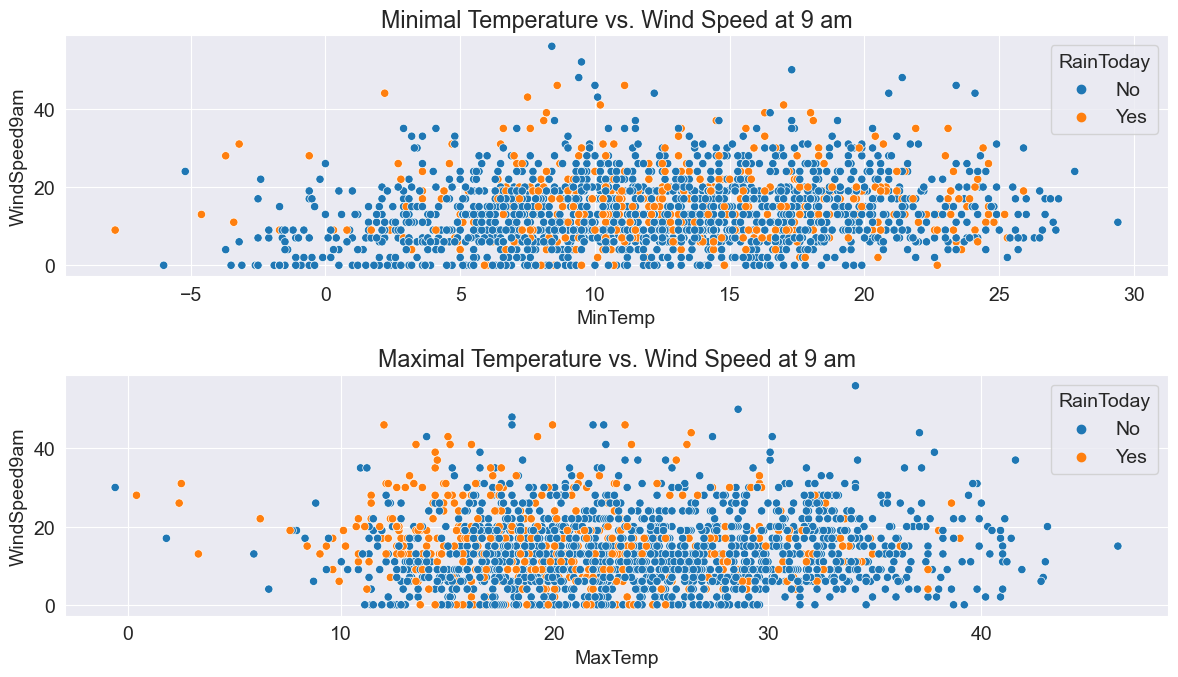

In [ ]:
fig, axes = plot_temp_pressure_scatter(
    df,
    x1="MinTemp",
    y1="WindSpeed9am",
    x2="MaxTemp",
    y2="WindSpeed9am",
    title1="Minimal Temperature vs. Wind Speed at 9 am",
    title2="Maximal Temperature vs. Wind Speed at 9 am",
)
plt.show()

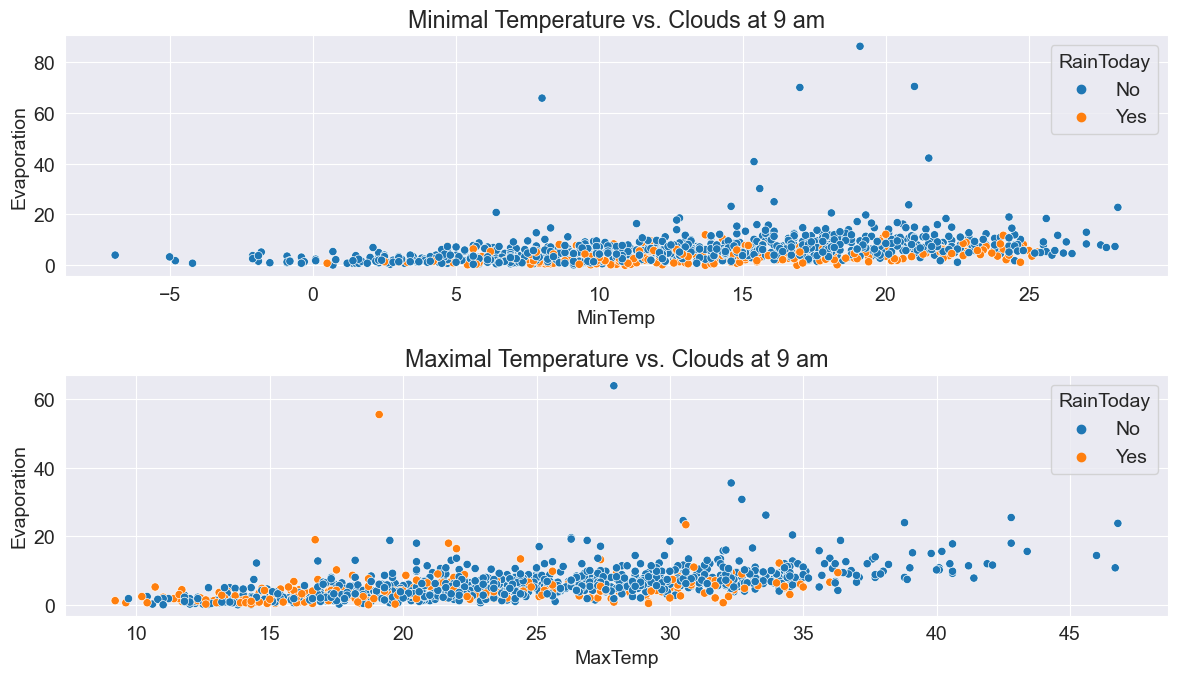

In [ ]:
fig, axes = plot_temp_pressure_scatter(
    df,
    x1="MinTemp",
    y1="Evaporation",
    x2="MaxTemp",
    y2="Evaporation",
    title1="Minimal Temperature vs. Clouds at 9 am",
    title2="Maximal Temperature vs. Clouds at 9 am",
)
plt.show()

## Preprocessing the Data

It might be a good idea to discard rows where `RainTomorrow` or `RainToday` values are missing to simplify our analysis and modeling (since one of them is the target variable and the other is likely very closely related). to the target variable).

In [ ]:
df.dropna(subset=["RainToday", "RainTomorrow"], inplace=True)

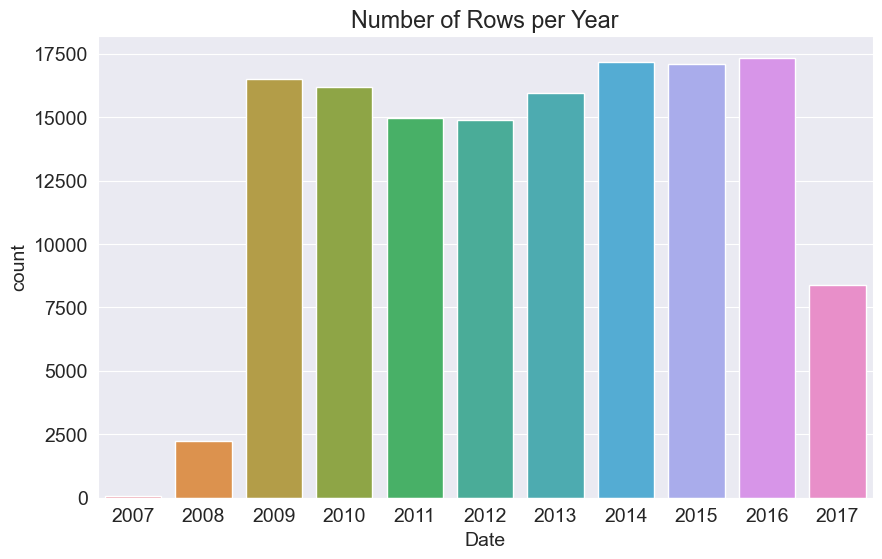

In [ ]:
plt.title("Number of Rows per Year")
sns.countplot(x=pd.to_datetime(df.Date).dt.year);

We'll train on data from the past and evaluate on data from the future.

In [ ]:
year = pd.to_datetime(df.Date).dt.year

train_df = df[year < 2015]
val_df = df[year == 2015]
test_df = df[year > 2015]

In [ ]:
print(train_df.shape, val_df.shape, test_df.shape)

(97988, 23) (17089, 23) (25710, 23)


In [ ]:
# Define feature and target columns
features = [col for col in df.columns if col not in "RainTomorrow"]
target = "RainTomorrow"

Create a copy to maintain the integrity of the data. By converting 'Yes'/'No' to 1/0, we make the target variable suitable for binary classification.

In [ ]:
# Separate features and target
X_train = train_df[features].copy()
y_train = train_df[target].apply(lambda x: 1 if x == "Yes" else 0).copy()
X_val = val_df[features].copy()
y_val = val_df[target].apply(lambda x: 1 if x == "Yes" else 0).copy()
X_test = test_df[features].copy()
y_test = test_df[target].apply(lambda x: 1 if x == "Yes" else 0).copy()

In [ ]:
print(df.dtypes.unique())

[dtype('O') dtype('float64')]


In [ ]:
# Preprocessing Pipeline
numeric_features = X_train.select_dtypes(include="float64").columns
categorical_features = [
    col
    for col in X_train.select_dtypes(include="object").columns
    if col != "RainTomorrow"
]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
# Save the preprocessor to a file
dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

When evaluating model performance, it is important to ensure that the same preprocessing is applied to the validation and test sets as was applied to the training set.

In [ ]:
# Fit the preprocessor
preprocessor.fit(X_train)

# Transform the data
X_train_preprocessed = preprocessor.transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

In [ ]:
print(X_train_preprocessed.shape, X_val_preprocessed.shape, X_test_preprocessed.shape)

(97988, 2644) (17089, 2644) (25710, 2644)


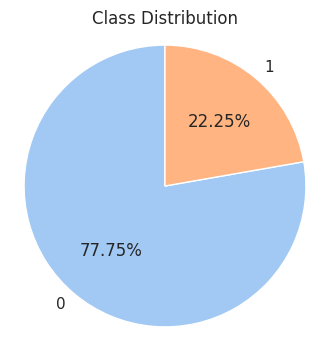

In [ ]:
# Check class distribution
class_counts = y_train.value_counts(normalize=True)

# Seaborn style
sns.set(style="whitegrid")

# Plotting the pie chart
plt.figure(figsize=(4, 4))
plt.title("Class Distribution")
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct="%.2f%%",
    colors=sns.color_palette("pastel"),
    startangle=90,
)
plt.axis("equal")

plt.show()

Due the imbalanced distribution of classes we´ll use stratified k-fold CV to maintain the proportion of classes in each fold.

## Model Training

We'll use `StackingClassifier` that combines the predictions of multiple base models (diverse classifiers) to generate a new model, often resulting in better overall performance compared to any individual model. This is particularly useful when different models capture different patterns in the data. By leveraging the strengths of various models, stacking can enhance predictive accuracy and robustness. By combining multiple models, stacking can reduce the risk of overfitting. The meta-model (final estimator) learns to generalize better by correcting the biases of base models, leading to improved performance on unseen data.

In [ ]:
# Base models
base_models = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    (
        "svc",
        LinearSVC(max_iter=10000, random_state=42),
    ),  # Efficient for high-dimensional data
    (
        "xgb",
        XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    ),  # 'logloss' is appropriate for binary classification
]

# Define the meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Define stacking classifier
stack_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
)

# Create a pipeline that includes preprocessing and the stacking classifier
pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("stackingclassifier", stack_clf)]
)

# Hyperparameter search space
param_distributions = {
    "stackingclassifier__lr__C": uniform(0.01, 10),
    "stackingclassifier__rf__n_estimators": randint(10, 300),
    "stackingclassifier__rf__max_depth": randint(1, 20),
    "stackingclassifier__svc__C": uniform(0.01, 10),
    "stackingclassifier__xgb__n_estimators": randint(50, 300),
    "stackingclassifier__xgb__max_depth": randint(3, 10),
    "stackingclassifier__xgb__learning_rate": uniform(0.01, 0.3),
    "stackingclassifier__final_estimator__C": uniform(0.01, 10),
}

In [ ]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    verbose=2,
    n_jobs=-1,
)

In [ ]:
%%time
# Fit the RandomizedSearchCV on the original training data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
CPU times: user 8min 55s, sys: 17.8 s, total: 9min 12s
Wall time: 2h 29min 44s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSp...
                                        'stackingclassifier__xgb__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f239ae89360>,
                                        'stackingclassifier__xgb__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f239ae89510>,
                                        'stackingclassifier__xgb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f239ae897e0>},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print('Best Hyperparameters:')
random_search.best_params_

Best Hyperparameters:


{'stackingclassifier__final_estimator__C': 9.27658865793794,
 'stackingclassifier__lr__C': 7.282719958564209,
 'stackingclassifier__rf__max_depth': 15,
 'stackingclassifier__rf__n_estimators': 224,
 'stackingclassifier__svc__C': 5.218342600258237,
 'stackingclassifier__xgb__learning_rate': 0.29835160730480476,
 'stackingclassifier__xgb__max_depth': 7,
 'stackingclassifier__xgb__n_estimators': 257}

In [ ]:
best_pipeline = random_search.best_estimator_
best_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Te...
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=7,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=257,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=42, ...))],
                                    final_estimator=LogisticRegression(C=9.27658865793794,
                                                                       max_iter=1000,
                                                                       random_state=42)))])

In [ ]:
# Evaluate the performance of your model during training
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean CV Accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')


Cross-Validation Accuracy Scores: [0.84794367 0.8527911  0.85054597 0.85079349 0.85344696]
Mean CV Accuracy: 0.8511 ± 0.0019


In [ ]:
# Predictions on the validation set
y_val_pred = best_pipeline.predict(X_val)

# Evaluation on the validation set
accuracy_val = accuracy_score(y_val, y_val_pred)
print(f'Validation Accuracy: {accuracy_val:.4f}')
print(classification_report(y_val, y_val_pred, target_names=["No", "Yes"]))

# Predictions on the test set
y_test_pred = best_pipeline.predict(X_test)

# Evaluation on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f'Test Accuracy: {accuracy_test:.4f}')
print(classification_report(y_test, y_test_pred, target_names=["No", "Yes"]))

Validation Accuracy: 0.8494
              precision    recall  f1-score   support

          No       0.86      0.97      0.91     13511
         Yes       0.79      0.38      0.52      3578

    accuracy                           0.85     17089
   macro avg       0.82      0.68      0.71     17089
weighted avg       0.84      0.85      0.83     17089

Test Accuracy: 0.8366
              precision    recall  f1-score   support

          No       0.85      0.96      0.90     19885
         Yes       0.76      0.41      0.53      5825

    accuracy                           0.84     25710
   macro avg       0.80      0.68      0.72     25710
weighted avg       0.83      0.84      0.82     25710



Based on the results, let's analyze the performance of your stacking classifier model for predicting rain in Australia:

1. Cross-Validation Results:
   - Mean CV Accuracy: 0.8511 ± 0.0019
   - This indicates that during training, the model achieved an average accuracy of about 85.11% with a small standard deviation, suggesting consistent performance across different folds.

2. Validation Set Performance:
   - Accuracy: 0.8494 (84.94%)
   - Precision for "No Rain": 0.86
   - Recall for "No Rain": 0.97
   - Precision for "Rain": 0.79
   - Recall for "Rain": 0.38

3. Test Set Performance:
   - Accuracy: 0.8366 (83.66%)
   - Precision for "No Rain": 0.85
   - Recall for "No Rain": 0.96
   - Precision for "Rain": 0.76
   - Recall for "Rain": 0.41

Analysis:

1. Overall Performance: The model performs well, with accuracies above 83% on both validation and test sets. This is a good baseline for weather prediction, considering the complexity of meteorological phenomena.

2. Consistency: The model's performance is relatively consistent across training (CV), validation, and test sets, which is a positive sign. The slight drop in accuracy from validation to test set (about 1.3%) is not unusual and suggests the model generalizes reasonably well to unseen data.

3. Class Imbalance: There appears to be a class imbalance issue. The model is much better at predicting "No Rain" than "Rain":
   - High recall for "No Rain" (0.96-0.97) but low recall for "Rain" (0.38-0.41)
   - This suggests the model is more likely to miss actual rainy days (more false negatives)

4. Precision vs Recall Trade-off: For the "Rain" class, the model has higher precision than recall. This means when it predicts rain, it's often correct, but it misses many actual rainy days.

5. F1-Score: The F1-score for "Rain" prediction (0.52-0.53) is much lower than for "No Rain" (0.90-0.91), further highlighting the class imbalance issue.

Recommendations:

1. Address Class Imbalance: Consider techniques like oversampling the minority class (SMOTE), undersampling the majority class, or adjusting class weights in the model.

2. Feature Engineering: Explore creating new features or transforming existing ones to better capture patterns leading to rain.

3. Ensemble Methods: Experiment with different combinations of base models or try other ensemble methods like gradient boosting.

4. Threshold Adjustment: Given the imbalance, adjusting the classification threshold might improve the recall for the "Rain" class at the cost of some precision.

5. Time Series Consideration: Since this is time-series data, consider incorporating lagged features or using time series specific models.

6. Domain Expert Input: Consult with meteorologists to understand if there are any domain-specific features or patterns that could be incorporated into the model.

7. Cost-Sensitive Learning: If missing a rainy day prediction is more costly than a false alarm, adjust the model to reflect this in its predictions.

Overall, the model provides a strong foundation for rain prediction. The main area for improvement is in better identifying the less common rainy days without significantly sacrificing the accuracy of "No Rain" predictions.

In [ ]:
def predict_and_plot(features, target, name=''):
    preds = best_pipeline.predict(features)
    accuracy = accuracy_score(target, preds)
    print(f"Accuracy: {(accuracy * 100):.2f}%")

    cf = confusion_matrix(target, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

    return preds

Accuracy: 86.60%


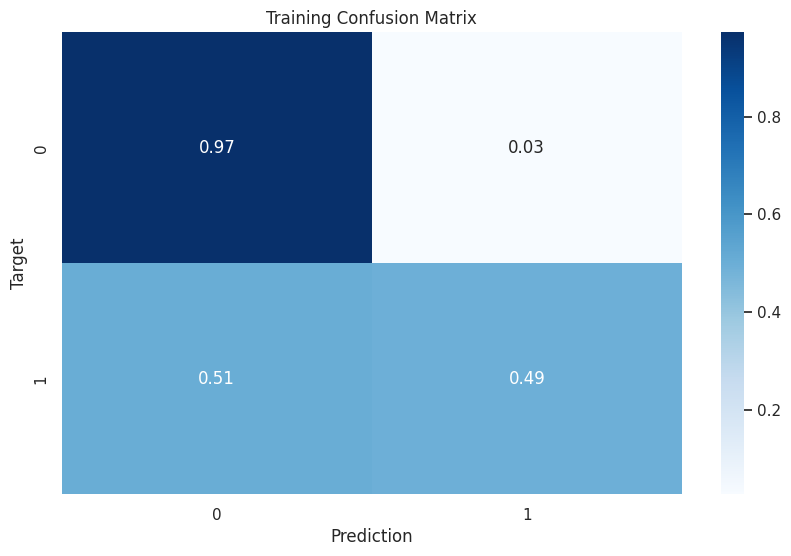

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
predict_and_plot(X_train, y_train, 'Training')

Accuracy: 84.94%


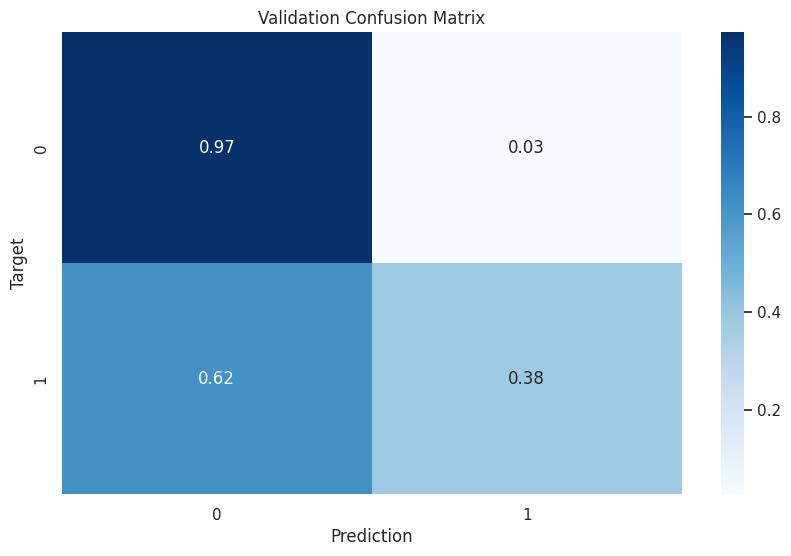

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
predict_and_plot(X_val, y_val, 'Validation')

Accuracy: 83.66%


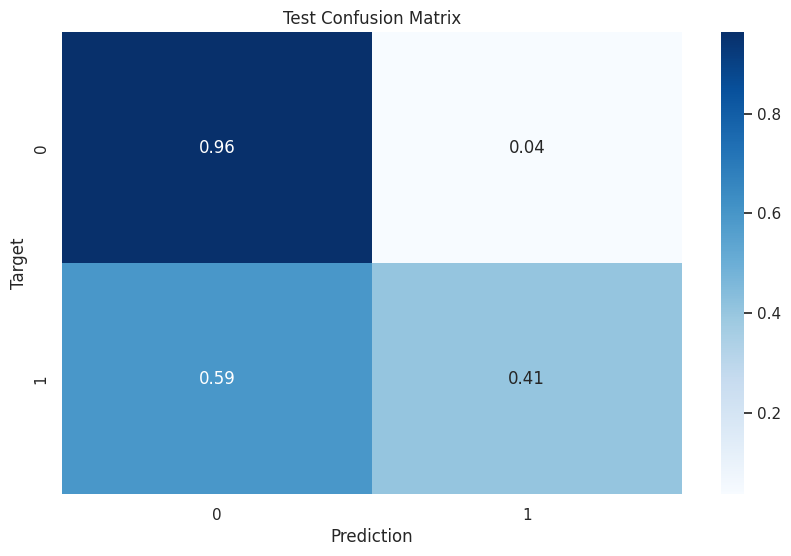

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
predict_and_plot(X_test, y_test, 'Test')

The model accuracy on the test and validation sets is around 84%, but how good is it?

Let's create two models: one that guesses randomly and another that always return "No". Both of these models completely ignore the inputs given to them. This is a good way to verify whether a model has actually learned something useful.

In [ ]:
def random_guess(features):
    # Generate random predictions (0 for "No", 1 for "Yes")
    random_preds = np.random.choice([0, 1], size=len(features))
    return random_preds

In [ ]:
def always_no(features):
    # Generate predictions (0 for "No")
    no_preds = np.zeros(len(features), dtype=int)
    return no_preds

In [ ]:
# Evaluate Random Guess Model
y_val_random_pred = random_guess(X_val)
y_test_random_pred = random_guess(X_test)

# Validation Set Performance
accuracy_val_random = accuracy_score(y_val, y_val_random_pred)
print(f'Random Guess Validation Accuracy: {accuracy_val_random:.4f}')

# Test Set Performance
accuracy_test_random = accuracy_score(y_test, y_test_random_pred)
print(f'Random Guess Test Accuracy: {accuracy_test_random:.4f}')

Random Guess Validation Accuracy: 0.5026
Random Guess Test Accuracy: 0.5012


In [ ]:
# Evaluate Always No Model
y_val_no_pred = always_no(X_val)
y_test_no_pred = always_no(X_test)

# Validation Set Performance
accuracy_val_no = accuracy_score(y_val, y_val_no_pred)
print(f'Always No Validation Accuracy: {accuracy_val_no:.4f}')

# Test Set Performance
accuracy_test_no = accuracy_score(y_test, y_test_no_pred)
print(f'Always No Test Accuracy: {accuracy_test_no:.4f}')

Always No Validation Accuracy: 0.7906
Always No Test Accuracy: 0.7734


Lucky for us our model is better that the two benckmark models.

In [ ]:
def plot_calibration_curve(y_true, y_prob):
    fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.plot(mean_predicted_value, fraction_of_positives, marker='.')
    plt.xlabel("Predicted probability")
    plt.ylabel("Actual probability")
    plt.title("Calibration Curve")
    plt.show()

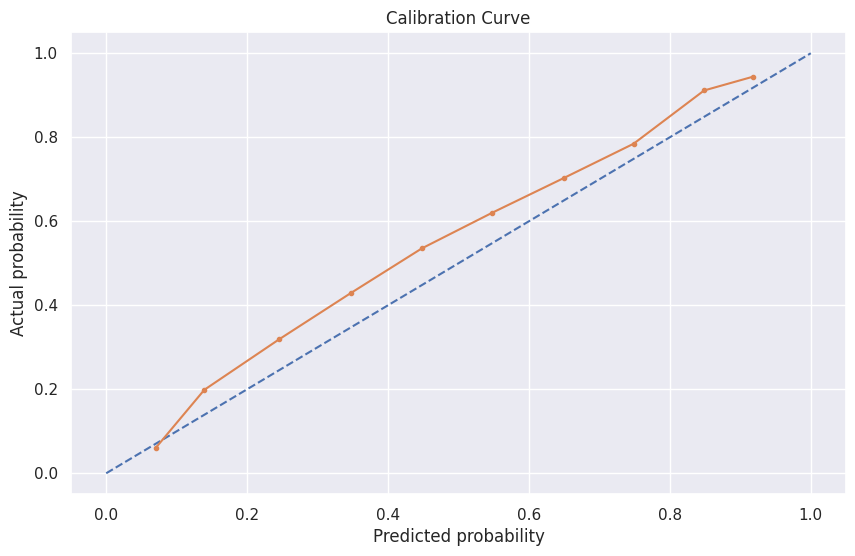

In [ ]:
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
plot_calibration_curve(y_test, y_prob)

This calibration curve plot provides insights into how well the model's predicted probabilities align with the actual observed probabilities of the positive class. Here's an interpretation of the plot:

1. Ideal Calibration: The dashed blue diagonal line represents perfect calibration, where predicted probabilities exactly match actual probabilities.

2. Model Performance: The orange line with dots represents your model's calibration. It's generally above the diagonal line, which suggests:

   a. The model is slightly overconfident for lower probabilities (up to about 0.6).
   b. It's slightly underconfident for higher probabilities (above 0.6).

3. Low Probabilities: For predicted probabilities below 0.2, the model appears well-calibrated as it closely follows the diagonal.

4. Mid-range Probabilities: Between 0.2 and 0.6, the model is overconfident. When it predicts a 40% chance of rain, for example, the actual probability is closer to 50%.

5. High Probabilities: Above 0.6, the model becomes slightly underconfident. When it predicts a very high chance of rain, the actual probability is even higher.

6. Overall Trend: The curve is relatively smooth and consistently close to the diagonal, indicating that the model is reasonably well-calibrated across most of the probability range.

7. Actionable Insights:
   - The model could benefit from recalibration, especially in the mid-probability range.
   - Users should be aware that mid-range predictions might slightly underestimate the true probability of rain.
   - Very high probability predictions are likely to be quite reliable, possibly even conservative.

In summary, while not perfect, this calibration curve suggests a reasonably well-calibrated model with some room for improvement in the mid-probability range. It's performing better than an uncalibrated model (which would show a more erratic or consistently offset curve) but could be fine-tuned for even better probability estimates.

## Feature Importance

In [ ]:
# Initialize dictionaries to store feature importance
feature_importance = {}

# Accessing base models from the StackingClassifier
base_models = best_pipeline.named_steps['stackingclassifier'].named_estimators_

# Loop through each base model and extract feature importance (for tree-based models)
for name, model in base_models.items():
    if name in ['rf', 'xgb']:  # Check if the model is a tree-based model
        feature_importance[name] = model.feature_importances_

# Aggregate feature importance across all tree-based models
aggregate_importance = {}
for feature in X_train.columns:
    feature_importance_values = [importance.get(feature, np.zeros_like(X_train[feature].values)) for importance in feature_importance.values() if feature in importance]
    if feature_importance_values:
        aggregate_importance[feature] = np.mean(feature_importance_values, axis=0)
    else:
        aggregate_importance[feature] = np.zeros_like(X_train[feature].values)

# Sort feature importance in descending order
sorted_importance = sorted(aggregate_importance.items(), key=lambda x: np.mean(x[1]), reverse=True)

# Print or visualize feature importance
for feature, importance in sorted_importance:
    print(f"{feature}: {np.mean(importance):.4f}")


Date: 0.0000
Location: 0.0000
MinTemp: 0.0000
MaxTemp: 0.0000
Rainfall: 0.0000
Evaporation: 0.0000
Sunshine: 0.0000
WindGustDir: 0.0000
WindGustSpeed: 0.0000
WindDir9am: 0.0000
WindDir3pm: 0.0000
WindSpeed9am: 0.0000
WindSpeed3pm: 0.0000
Humidity9am: 0.0000
Humidity3pm: 0.0000
Pressure9am: 0.0000
Pressure3pm: 0.0000
Cloud9am: 0.0000
Cloud3pm: 0.0000
Temp9am: 0.0000
Temp3pm: 0.0000
RainToday: 0.0000


If all feature importances are returning as 0.0000, it typically indicates that the tree-based models (RandomForestClassifier or XGBClassifier) did not effectively learn from the features or did not find them significant for prediction. Here are some common reasons why this might happen:

1. **Data Quality Issues**: Ensure that your data is clean and meaningful. If features are not informative or are highly correlated with other features, tree-based models may not assign them high importance.

2. **Model Complexity**: Sometimes, models may not capture the nuances of relationships between features and the target variable, leading to uniformly low feature importance.

3. **Overfitting or Underfitting**: If the models are overfitted or underfitted, they may fail to capture important patterns in the data, resulting in low or misleading feature importance scores.

4. **Hyperparameters**: Check if the hyperparameters of your models are appropriately tuned. Incorrect hyperparameters can affect model performance and the ability to learn from features.


## Making Predictions

In [ ]:
best_pipeline.predict(X_train)[0]

0

In [ ]:
best_pipeline.predict_proba(X_train)[0]

array([0.87695879, 0.12304121])

In [ ]:
# Example data for today (replace this with actual data)
today_data = {
    'Date': ['2012-07-15'],
    'Location': ['Sydney'],
    'MinTemp': [12.0],
    'MaxTemp': [22.0],
    'Rainfall': [0.0],
    'Evaporation': [5.0],
    'Sunshine': np.nan,
    'WindGustDir': ['NW'],
    'WindGustSpeed': [30.0],
    'WindDir9am': ['N'],
    'WindDir3pm': ['NW'],
    'WindSpeed9am': [15.0],
    'WindSpeed3pm': [20.0],
    'Humidity9am': [65.0],
    'Humidity3pm': [45.0],
    'Pressure9am': [1015.0],
    'Pressure3pm': [1012.0],
    'Cloud9am': [4.0],
    'Cloud3pm': [3.0],
    'Temp9am': [14.0],
    'Temp3pm': [20.0],
    'RainToday': ['No']
}

In [ ]:
# Convert to DataFrame
today_df = pd.DataFrame(today_data)

# Make prediction
rain_tomorrow_pred = best_pipeline.predict(today_df)

# Predict probabilities
rain_tomorrow_pred_proba = best_pipeline.predict_proba(today_df)

# Convert prediction to 'Yes'/'No'
rain_tomorrow_pred_label = 'Yes' if rain_tomorrow_pred[0] == 1 else 'No'
rain_tomorrow_pred_prob = rain_tomorrow_pred_proba[0][1] * 100

print(f"Will it rain tomorrow? {rain_tomorrow_pred_label}")
print(f"Probability of rain: {rain_tomorrow_pred_prob:.2f}")

Will it rain tomorrow? No
Probability of rain: 15.90


## Save the Model

Why Use joblib?
- Efficiency: joblib is more efficient for storing large NumPy arrays, which are often used in machine learning models.
- Compatibility: It works seamlessly with scikit-learn models and can handle complex objects like pipelines (Pipeline objects).

In [ ]:
# Save the model to a file
dump(best_pipeline, 'weather_prediction_model.joblib')

['weather_prediction_model.joblib']

In [ ]:
# Load the saved model
loaded_model = load('weather_prediction_model.joblib')

In [ ]:
def predict_rain_tomorrow(model_path, input_data):
    """
    Load the saved model (StackingClassifier) and make predictions for rain tomorrow.

    Parameters:
    model_path (str): Path to the saved model file.
    input_data (dict): Dictionary containing the input features for prediction.

    Returns:
    tuple: Predicted label ('Yes'/'No') and the probability of rain.
    """
    # Load the saved model
    loaded_model = load(model_path)

    # Convert input data to DataFrame
    input_df = pd.DataFrame(input_data)

    # Make prediction
    rain_tomorrow_pred = loaded_model.predict(input_df)

    # Predict probabilities
    rain_tomorrow_pred_proba = loaded_model.predict_proba(input_df)

    # Convert prediction to 'Yes'/'No'
    rain_tomorrow_pred_label = 'Yes' if rain_tomorrow_pred[0] == 1 else 'No'
    rain_tomorrow_pred_prob = rain_tomorrow_pred_proba[0][1] * 100

    return rain_tomorrow_pred_label, rain_tomorrow_pred_prob

In [ ]:
today_data = {
    "Date": ["2015-07-01"],
    "Location": ["Albury"],
    "MinTemp": [20.0],
    "MaxTemp": [30.0],
    "Rainfall": [0.0],
    "Evaporation": [np.nan],
    "Sunshine": [np.nan],
    "WindGustDir": ["N"],
    "WindGustSpeed": [20.0],
    "WindDir9am": ["N"],
    "WindDir3pm": ["N"],
    "WindSpeed9am": [10.0],
    "WindSpeed3pm": [15.0],
    "Humidity9am": [70.0],
    "Humidity3pm": [85.0],
    "Pressure9am": [1015.0],
    "Pressure3pm": [1013.0],
    "Cloud9am": [4.0],
    "Cloud3pm": [2.0],
    "Temp9am": [25.0],
    "Temp3pm": [35.0],
    "RainToday": ["Yes"]
}

model_path = 'weather_prediction_model.joblib'
rain_tomorrow_label, rain_tomorrow_prob = predict_rain_tomorrow(model_path, today_data)

print(f"Will it rain tomorrow? {rain_tomorrow_label}")
print(f"Probability of rain: {rain_tomorrow_prob:.2f}")

Will it rain tomorrow? No
Probability of rain: 19.61


## Summary Evaluation for each Algorithm

In [ ]:
%%time
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)

    # Validation set performance
    model_val_accuracy = accuracy_score(y_val, y_val_pred)
    model_val_f1 = f1_score(y_val, y_val_pred)
    model_val_precision = precision_score(y_val, y_val_pred)
    model_val_recall = recall_score(y_val, y_val_pred)

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)

    # Print performance metrics
    print('Model Performance on Training Set')
    print(f'- Accuracy: {model_train_accuracy:.4f}')
    print(f'- F1 score: {model_train_f1:.4f}')
    print(f'- Precision: {model_train_precision:.4f}')
    print(f'- Recall: {model_train_recall:.4f}')
    if hasattr(model, 'predict_proba'):
        model_train_rocauc_score = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
        print(f'- ROC AUC score: {model_train_rocauc_score:.4f}')
    print('-' * 40)

    print('Model Performance on Validation Set')
    print(f'- Accuracy: {model_val_accuracy:.4f}')
    print(f'- F1 score: {model_val_f1:.4f}')
    print(f'- Precision: {model_val_precision:.4f}')
    print(f'- Recall: {model_val_recall:.4f}')
    if hasattr(model, 'predict_proba'):
        model_val_rocauc_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        print(f'- ROC AUC score: {model_val_rocauc_score:.4f}')
    print('-' * 40)

    print('Model Performance on Test Set')
    print(f'- Accuracy: {model_test_accuracy:.4f}')
    print(f'- F1 score: {model_test_f1:.4f}')
    print(f'- Precision: {model_test_precision:.4f}')
    print(f'- Recall: {model_test_recall:.4f}')
    if hasattr(model, 'predict_proba'):
        model_test_rocauc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        print(f'- ROC AUC score: {model_test_rocauc_score:.4f}')
    print('=' * 40)
    print('\n')

# Define models
models = {
    'Linear Support Vector Classification': LinearSVC(max_iter=10000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Extreme Gradient Boosting Classifier': XGBClassifier(random_state=42),
}

# Evaluate each model
for model_name, model in models.items():
    print(f'Evaluating {model_name}')
    evaluate_model(model, X_train_preprocessed, y_train, X_val_preprocessed, y_val, X_test_preprocessed, y_test)

Evaluating Linear Support Vector Classification
Model Performance on Training Set
- Accuracy: 0.8675
- F1 score: 0.6612
- Precision: 0.7665
- Recall: 0.5814
----------------------------------------
Model Performance on Validation Set
- Accuracy: 0.8527
- F1 score: 0.5564
- Precision: 0.7526
- Recall: 0.4413
----------------------------------------
Model Performance on Test Set
- Accuracy: 0.8387
- F1 score: 0.5674
- Precision: 0.7233
- Recall: 0.4668


Evaluating Logistic Regression
Model Performance on Training Set
- Accuracy: 0.8662
- F1 score: 0.6578
- Precision: 0.7632
- Recall: 0.5780
- ROC AUC score: 0.9044
----------------------------------------
Model Performance on Validation Set
- Accuracy: 0.8531
- F1 score: 0.5622
- Precision: 0.7473
- Recall: 0.4505
- ROC AUC score: 0.8719
----------------------------------------
Model Performance on Test Set
- Accuracy: 0.8392
- F1 score: 0.5708
- Precision: 0.7218
- Recall: 0.4721
- ROC AUC score: 0.8567


Evaluating Random Forest Classi

## Inteprtarion of 'evaluate_model' function

The `evaluate_model` function assesses the performance of machine learning models on training, validation, and test datasets. It computes various performance metrics, including accuracy, F1 score, precision, recall, and ROC AUC score (if applicable). The interpretation of these metrics helps in understanding how well each model is performing.

### Linear Support Vector Classification (SVC)

- The model performs well on the training set with a reasonable accuracy and a balanced precision-recall trade-off.
- The performance drops slightly on the validation and test sets, indicating some overfitting, but it still maintains decent precision and recall.
  
### Logistic Regression

- Logistic Regression shows similar performance to SVC but with a slightly lower F1 score and ROC AUC score.
- The model generalizes well with consistent performance across training, validation, and test sets.

### Random Forest Classifier

- The model is overfitting the training data, as indicated by perfect scores on the training set.
- Performance on validation and test sets is significantly lower, suggesting the model does not generalize well.

### Extreme Gradient Boosting Classifier (XGBoost)

- XGBoost performs well on the training set with high accuracy and F1 score, indicating it captures complex patterns effectively.
- It also generalizes well to the validation and test sets, showing slightly better performance than other models, particularly in recall and F1 score.

### Overall Interpretation:
- **Linear SVC** and **Logistic Regression** show consistent but modest performance across all sets.
- **Random Forest** is overfitting, performing perfectly on the training set but poorly on validation and test sets.
- **XGBoost** provides the best balance between fitting the training data and generalizing to validation and test sets, making it a strong candidate for further tuning and deployment.

## Refined Hyperparameter Search Space

### RandomForestClassifier Hyperparameters
- `n_estimators`: The number of trees in the forest. Too many trees can lead to overfitting, while too few might underfit. A balanced range is needed.
- `max_depth`: The maximum depth of the trees. Limiting the depth can prevent the model from learning overly complex patterns that only exist in the training data.
- `min_samples_split`: The minimum number of samples required to split an internal node. Increasing this can help reduce overfitting.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. Setting this to higher values can smooth the model.
- `max_features`: The number of features to consider when looking for the best split. Limiting this can reduce the variance.

### XGBClassifier Hyperparameters
- `n_estimators`: The number of boosting rounds. More rounds can capture more complex patterns, but too many can overfit.
- `max_depth`: The maximum depth of the trees. Similar to RandomForest, limiting depth can prevent overfitting.
- `learning_rate`: The learning rate shrinks the contribution of each tree by learning_rate. Lower values can lead to better generalization but require more boosting rounds.
- `subsample`: The fraction of samples to be used for fitting the individual base learners. Lower values can prevent overfitting.
- `colsample_bytree`: The fraction of features to be used for each tree. Limiting this can help prevent overfitting.

**Code Integration**

```python
from scipy.stats import randint, uniform

param_distributions = {
    # RandomForestClassifier hyperparameters
    "stackingclassifier__rf__n_estimators": randint(50, 200),
    "stackingclassifier__rf__max_depth": randint(3, 15),
    "stackingclassifier__rf__min_samples_split": randint(2, 10),
    "stackingclassifier__rf__min_samples_leaf": randint(1, 10),
    "stackingclassifier__rf__max_features": uniform(0.5, 0.5),

    # XGBClassifier hyperparameters
    "stackingclassifier__xgb__n_estimators": randint(50, 200),
    "stackingclassifier__xgb__max_depth": randint(3, 10),
    "stackingclassifier__xgb__learning_rate": uniform(0.01, 0.2),
    "stackingclassifier__xgb__subsample": uniform(0.6, 0.4),
    "stackingclassifier__xgb__colsample_bytree": uniform(0.6, 0.4),
}
```

### Explanation of the Hyperparameters:
1. **RandomForestClassifier**:
    - `n_estimators`: 50 to 200 trees to balance between performance and overfitting.
    - `max_depth`: 3 to 15 to limit the complexity of the model.
    - `min_samples_split`: 2 to 10 to ensure that splits are significant.
    - `min_samples_leaf`: 1 to 10 to smooth the model by limiting leaf size.
    - `max_features`: 0.5 to 1.0 (using 50% to 100% of features for each split) to prevent the model from considering all features every time, which can help reduce variance.

2. **XGBClassifier**:
    - `n_estimators`: 50 to 200 rounds to provide sufficient learning opportunities without overfitting.
    - `max_depth`: 3 to 10 to limit the complexity of each tree.
    - `learning_rate`: 0.01 to 0.2 to ensure gradual learning, with the possibility of fine-tuning.
    - `subsample`: 0.6 to 1.0 to randomly sample a fraction of training data for each boosting round, reducing overfitting.
    - `colsample_bytree`: 0.6 to 1.0 to use a fraction of features for each tree, reducing overfitting.


# How to improve the model

Improving the model can involve several strategies, ranging from data preprocessing enhancements to exploring advanced machine learning techniques. Here are some suggestions to improve the predictive performance of the weather prediction model:

### 1. Data Quality and Feature Engineering

#### Handling Missing Data:
- **Advanced Imputation Techniques:** Beyond simple strategies like median or mode, consider using k-nearest neighbors (KNN) or multivariate imputation by chained equations (MICE).

#### Feature Engineering:
- **Temporal Features:** Extract additional features from the `Date` column, such as the month, day of the week, and season, which can capture seasonality patterns.
- **Interaction Features:** Create interaction terms between different weather attributes, such as `Humidity * Temperature` or `WindSpeed * Humidity`.
- **Rolling Statistics:** Calculate rolling averages, maximums, minimums, and standard deviations over previous days' weather data to capture trends.

#### Encoding Categorical Variables:
- **Target Encoding:** For high-cardinality categorical features like `Location`, consider target encoding, where the feature is replaced with the mean target value for each category.

### 2. Model Selection and Hyperparameter Tuning

#### Model Selection:
- **Ensemble Methods:** Beyond stacking, consider other ensemble methods like Gradient Boosting Machines (GBM), CatBoost, or LightGBM.
- **Neural Networks:** Explore deep learning models, particularly Recurrent Neural Networks (RNNs) or Long Short-Term Memory networks (LSTMs), which can capture temporal dependencies in the data.

#### Hyperparameter Tuning:
- **Grid Search:** Conduct a more exhaustive hyperparameter search with Grid Search for a finer exploration of hyperparameter space.
- **Bayesian Optimization:** Use Bayesian optimization techniques, such as the `optuna` or `hyperopt` libraries, for efficient hyperparameter tuning.

### 3. Model Evaluation and Validation

#### Cross-Validation:
- **Time Series Cross-Validation:** Use a time series cross-validation strategy like TimeSeriesSplit to ensure that the model is evaluated on temporally consistent training and validation sets.

#### Evaluation Metrics:
- **Precision-Recall Trade-off:** Focus on precision and recall, especially if predicting rain is more critical (e.g., minimizing false negatives). Use metrics like the F1 score or area under the precision-recall curve (PR AUC).

### 4. External Data Sources

#### Incorporate Additional Data:
- **Weather Forecast Data:** Include forecast data from meteorological services for more accurate predictions.
- **Geographical Data:** Integrate geographical features such as altitude, latitude, and longitude, which can influence weather patterns.

### 5. Model Interpretability and Monitoring

#### Model Interpretability:
- **SHAP Values:** Use SHAP (SHapley Additive exPlanations) to understand feature importance and interactions, which can provide insights for further feature engineering.

#### Model Monitoring:
- **Drift Detection:** Implement model monitoring to detect data drift or changes in feature distributions over time, which can affect model performance.

### Implementation Example

Here's how you can incorporate some of these improvements into the existing pipeline:

#### Advanced Imputation and Feature Engineering:
```python
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Imputer using IterativeImputer (MICE)
numeric_transformer = Pipeline(steps=[
    ("imputer", IterativeImputer(random_state=42)),
    ("scaler", MinMaxScaler())
])

# Adding temporal features
for df in [train_df, val_df, test_df]:
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Season'] = df['Date'].dt.month % 12 // 3 + 1

# New feature list
features = [col for col in df.columns if col not in ["Date", "RainTomorrow"]]
numeric_features = [col for col in features if df[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in features if df[col].dtype == 'object']

# Update preprocessor with new features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Transform the data
preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)
```

#### Model Selection and Hyperparameter Tuning:
```python
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit

# Define cross-validation strategy
tscv = TimeSeriesSplit(n_splits=5)

# Example using LightGBM
lgbm = LGBMClassifier(random_state=42)
param_distributions = {
    "num_leaves": randint(20, 150),
    "learning_rate": uniform(0.01, 0.3),
    "n_estimators": randint(50, 500),
    "max_depth": randint(3, 10)
}

random_search_lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions,
    n_iter=20,
    cv=tscv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search_lgbm.fit(X_train_preprocessed, y_train)

# Best hyperparameters and performance
print("Best Hyperparameters for LGBM:")
print(random_search_lgbm.best_params_)
print(f"Best CV Accuracy: {random_search_lgbm.best_score_:.4f}")

# Evaluation on validation set
y_val_pred = random_search_lgbm.best_estimator_.predict(X_val_preprocessed)
print(f'Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}')
print(classification_report(y_val, y_val_pred, target_names=["No", "Yes"]))
```

### Model Interpretability with SHAP
SHAP values provide insights into how each feature contributes to the model's predictions.

### Model Monitoring with MLflow
MLflow helps track and log model parameters, metrics, and artifacts.

```python
# Start an MLflow run
with mlflow.start_run():

    # Fit the RandomizedSearchCV on the original training data
    random_search.fit(X_train, y_train)

    # Log the best model
    mlflow.sklearn.log_model(random_search.best_estimator_, "best_model")
    
    # Best Hyperparameters
    best_params = random_search.best_params_
    print('Best Hyperparameters:')
    print(best_params)

    # Log best hyperparameters
    mlflow.log_params(best_params)

    # Evaluate the performance of your model during training
    cv_scores = random_search.cv_results_['mean_test_score']
    mean_cv_accuracy = np.mean(cv_scores)
    std_cv_accuracy = np.std(cv_scores)
    print(f'Mean CV Accuracy: {mean_cv_accuracy:.4f} ± {std_cv_accuracy:.4f}')

    # Log CV metrics
    mlflow.log_metric("mean_cv_accuracy", mean_cv_accuracy)
    mlflow.log_metric("std_cv_accuracy", std_cv_accuracy)

    # Predictions on the validation set
    y_val_pred = random_search.best_estimator_.predict(X_val)

    # Evaluation on the validation set
    accuracy_val = accuracy_score(y_val, y_val_pred)
    print(f'Validation Accuracy: {accuracy_val:.4f}')
    print(classification_report(y_val, y_val_pred, target_names=["No", "Yes"]))

    # Log validation accuracy
    mlflow.log_metric("validation_accuracy", accuracy_val)

    # Predictions on the test set
    y_test_pred = random_search.best_estimator_.predict(X_test)

    # Evaluation on the test set
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print(f'Test Accuracy: {accuracy_test:.4f}')
    print(classification_report(y_test, y_test_pred, target_names=["No", "Yes"]))

    # Log test accuracy
    mlflow.log_metric("test_accuracy", accuracy_test)

    # SHAP analysis
    explainer = shap.Explainer(random_search.best_estimator_.named_steps['stackingclassifier'])
    shap_values = explainer.shap_values(X_test)

    # Summary plot
    shap.summary_plot(shap_values, X_test)

    # Log SHAP values as artifact
    shap_values_path = "shap_values.npy"
    np.save(shap_values_path, shap_values)
    mlflow.log_artifact(shap_values_path)

    # End the MLflow run
    mlflow.end_run()

print("MLflow run completed and logged.")
```

### Explanation

1. **Data Preprocessing**:
   - The `Date` column is converted to datetime, and rows with missing `RainToday` or `RainTomorrow` values are dropped.
   - Temporal features such as `Month`, `Day`, `DayOfWeek`, and `Season` are added.

2. **Pipeline**:
   - The preprocessing steps are set up using `IterativeImputer`, `MinMaxScaler`, and `OneHotEncoder`.

3. **Model Training**:
   - A stacking classifier is created with a meta-model.
   - Hyperparameters are tuned using `RandomizedSearchCV` and `TimeSeriesSplit`.

4. **Model Monitoring**:
   - The MLflow run logs the best model, hyperparameters, cross-validation scores, and test/validation accuracy.
   - SHAP values are calculated for model interpretability and logged as an artifact in MLflow.
   - A summary plot for SHAP values is generated to visualize feature importance.

By integrating SHAP for interpretability and MLflow for monitoring, you can better understand your model's decisions and track its performance over time.


Implementing Recurrent Neural Networks (RNNs) or Long Short-Term Memory (LSTM) networks can significantly improve the performance of models dealing with time-series data. In this example, we will use LSTM networks due to their ability to handle long-term dependencies more effectively than vanilla RNNs.

We will use Keras, a high-level neural networks API, to implement the LSTM model. This example assumes you are working with the same weather dataset.

### Implementation Steps:

1. **Data Preprocessing**:
    - Convert the dataset to a format suitable for time-series analysis.
    - Normalize the features.
    - Create sequences of data points for training the LSTM model.

2. **Model Building**:
    - Define the LSTM architecture.
    - Compile the model.

3. **Model Training**:
    - Train the model on the training data.
    - Evaluate the model on validation and test sets.

4. **Model Monitoring with MLflow**:
    - Track model parameters, metrics, and performance using MLflow.


#### Code Integration

```python
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import mlflow.keras

# Assuming 'df' is the DataFrame already loaded

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Drop rows where RainTomorrow or RainToday are missing
df.dropna(subset=["RainToday", "RainTomorrow"], inplace=True)

# Add temporal features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Season'] = (df['Date'].dt.month % 12 // 3) + 1

# Define feature and target columns
features = [col for col in df.columns if col not in ['Date', 'RainTomorrow']]
target = 'RainTomorrow'

# Separate features and target
X = df[features].copy()
y = df[target].apply(lambda x: 1 if x == 'Yes' else 0).copy()

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert to sequences for LSTM
def create_sequences(data, target, time_steps=1):
    sequences = []
    labels = []
    for i in range(len(data) - time_steps):
        sequences.append(data[i:(i + time_steps)])
        labels.append(target[i + time_steps])
    return np.array(sequences), np.array(labels)

# Define time steps
time_steps = 10

# Create sequences
X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

# Split the data into train, validation, and test sets
train_size = int(0.7 * len(X_seq))
val_size = int(0.2 * len(X_seq))
test_size = len(X_seq) - train_size - val_size

X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_val, y_val = X_seq[train_size:train_size+val_size], y_seq[train_size:train_size+val_size]
X_test, y_test = X_seq[train_size+val_size:], y_seq[train_size+val_size:]

# Define LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(time_steps, X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Start an MLflow run
with mlflow.start_run():
    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping]
    )

    # Log the model
    mlflow.keras.log_model(model, "lstm_model")
    
    # Log model parameters
    mlflow.log_param("time_steps", time_steps)
    mlflow.log_param("units", 50)
    mlflow.log_param("dropout_rate", 0.2)
    mlflow.log_param("optimizer", "adam")

    # Evaluate the model on the validation set
    val_loss, val_accuracy = model.evaluate(X_val, y_val)
    print(f'Validation Accuracy: {val_accuracy:.4f}')

    # Log validation accuracy
    mlflow.log_metric("val_accuracy", val_accuracy)

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(classification_report(y_test, model.predict_classes(X_test), target_names=["No", "Yes"]))

    # Log test accuracy
    mlflow.log_metric("test_accuracy", test_accuracy)

    # End the MLflow run
    mlflow.end_run()

print("MLflow run completed and logged.")
```

### Explanation

1. **Data Preprocessing**:
    - Convert the `Date` column to datetime and drop rows with missing values in `RainToday` and `RainTomorrow`.
    - Add temporal features (`Month`, `Day`, `DayOfWeek`, `Season`).
    - Normalize features using `MinMaxScaler`.
    - Convert data to sequences suitable for LSTM training using the `create_sequences` function.

2. **Model Building**:
    - Define an LSTM model with two LSTM layers and dropout for regularization.
    - Use a `sigmoid` activation function for binary classification.

3. **Model Training**:
    - Train the model with early stopping to prevent overfitting.
    - Log model parameters, metrics, and performance using MLflow.

4. **Model Evaluation**:
    - Evaluate the model on validation and test sets.
    - Log validation and test accuracies with MLflow.

By using LSTM networks, you can effectively capture temporal dependencies in your time-series data, improving the accuracy of your predictions. Integrating with MLflow allows you to track the entire experiment, making it easier to reproduce and analyze results.

## Conclusion:
While the model demonstrates good overall accuracy, especially in predicting no rain, there is room for improvement in predicting rain events (class 'Yes'). Consider exploring techniques such as adjusting class weights, feature engineering, or exploring different model architectures to potentially improve performance on the rain prediction task. Additionally, interpreting feature importance or using model interpretability techniques could provide insights into factors influencing these predictions, helping refine the model further.